In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from multicam_tng.multicam2 import multicam_prediction
from multicam.qt import qt
from scipy.stats import spearmanr


from astropy.table import Table
TNG_H = 0.6774
COLOR_CUT = 1.0  # Changed a little bit


In [45]:
## Compute TPCF ###
from halotools.mock_observables import return_xyz_formatted_array, tpcf_jackknife, tpcf


In [46]:

def generate_randoms(Lbox, number):
    """Generate randoms to be used for tpcf_jackknife
    Args:
        Lbox: size of TNG simulation box
        number: desired number of randoms, i.e. 10,000
    Return:
        Nran: xyz formatted array of uniform random variables
    """
    Xran = np.random.uniform(0, Lbox, number)
    Yran = np.random.uniform(0, Lbox, number)
    Zran = np.random.uniform(0, Lbox, number)
    Nran = return_xyz_formatted_array(Xran, Yran, Zran)
    return Nran


In [ ]:

# -----------------------------
# Load data
# -----------------------------
hydro_full = Table.read("../../data/hydro_final.ecsv")
len(hydro_full)

101364

In [8]:

# Stellar mass cut
# hydro_full = hydro_full[
#     hydro_full['StellarMass'] >= (1.4e8 * TNG_H)
# ]
# this cut can potentially bias the results so we avoid it

# Add z12
hydro_full['z12'] = (1 / hydro_full['a12']) - 1

In [9]:
# cut based on mpeak
log_mpeak = np.log10(hydro_full['mpeak'])
mpeak_cut_mask = (log_mpeak > 11) & (log_mpeak < 12)
hydro_full = hydro_full[mpeak_cut_mask]
len(hydro_full)

11310

In [13]:

# -----------------------------
# Define SHAM baseline
# -----------------------------
log10_mpeak = np.log10(hydro_full['mpeak'].data)
log10_stellar_mass = np.log10(hydro_full['stellar_mass'].data)

print(len(log10_mpeak), len(log10_stellar_mass))
assert len(log10_mpeak) == len(log10_stellar_mass)

# SHAM mean relation (NO scatter)
logmstar_sham = qt(
    log10_mpeak,
    log10_stellar_mass  # if your implementation requires it
)


11310 11310


In [14]:

star_mask = (log10_stellar_mass > 9.5) & (log10_stellar_mass < 10.2)
hydro_mstar_cut = hydro_full[star_mask]

sham_mask = (logmstar_sham > 9.5) & (logmstar_sham < 10.2)
hydro_mstar_pred = hydro_full[sham_mask]


len(hydro_mstar_cut), len(hydro_mstar_pred)


(4001, 4001)

In [86]:
# CAM prediction for color
# possibly resample
_color = np.random.choice(hydro_mstar_cut['color'].data, size=len(hydro_mstar_cut), replace=True)
# _color = hydro_mstar_cut['color']
color_cam_pred = qt(hydro_mstar_pred['z12'].data, _color)
color_cam_pred.shape

(4001,)

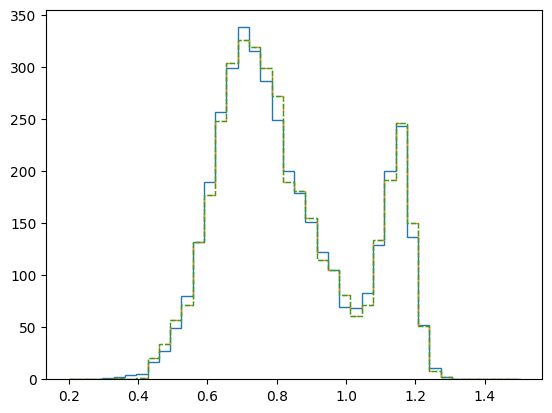

In [87]:
bins = np.linspace(0.2, 1.5, 41)

plt.hist(hydro_mstar_cut['color'], bins=bins, histtype='step')
plt.hist(color_cam_pred, bins=bins, histtype='step', linestyle='-.');
plt.hist(_color, bins=bins, histtype='step', linestyle='--');
# shoudl be exactly the same

In [88]:
spearmanr(hydro_mstar_cut['color'], color_cam_pred), spearmanr(_color, color_cam_pred)

(SignificanceResult(statistic=np.float64(0.2732347500452779), pvalue=np.float64(1.928360278109757e-69)),
 SignificanceResult(statistic=np.float64(-0.007370166903311622), pvalue=np.float64(0.6411802796082186)))

## Clustering (CAM)

In [89]:
Lbox = 110.7 * TNG_H # TNG box size in Mpc /h 
rbins = np.logspace(np.log10(0.1), np.log10(24.9), 16)
rbin_centers = 0.5 * (rbins[1:] + rbins[:-1])
randoms = generate_randoms(Lbox, 50000)
randoms.shape

(50000, 3)

In [90]:
red_pred = hydro_mstar_pred[color_cam_pred > COLOR_CUT]
blue_pred = hydro_mstar_pred[color_cam_pred <= COLOR_CUT]

true_color = hydro_mstar_cut['color']
red_true = hydro_mstar_cut[true_color > COLOR_CUT]
blue_true = hydro_mstar_cut[true_color <= COLOR_CUT]


In [91]:




xyz_red = return_xyz_formatted_array(red_true['x'].data, red_true['y'].data, red_true['z'].data)
xyz_blue = return_xyz_formatted_array(blue_true['x'].data, blue_true['y'].data, blue_true['z'].data)


xi_red_true = tpcf(
    xyz_red,
    rbins,
    randoms=randoms,
    period=Lbox,
    num_threads='max'
)

xi_blue_true = tpcf(
    xyz_blue,
    rbins,
    randoms=randoms,
    period=Lbox,
    num_threads='max'
)



In [92]:



xyz_red = return_xyz_formatted_array(red_pred['x'].data, red_pred['y'].data, red_pred['z'].data)
xyz_blue = return_xyz_formatted_array(blue_pred['x'].data, blue_pred['y'].data, blue_pred['z'].data)


xi_red_cam = tpcf(
    xyz_red,
    rbins,
    randoms=randoms,
    period=Lbox,
    num_threads='max'
)

xi_blue_cam = tpcf(
    xyz_blue,
    rbins,
    randoms=randoms,
    period=Lbox,
    num_threads='max'
)



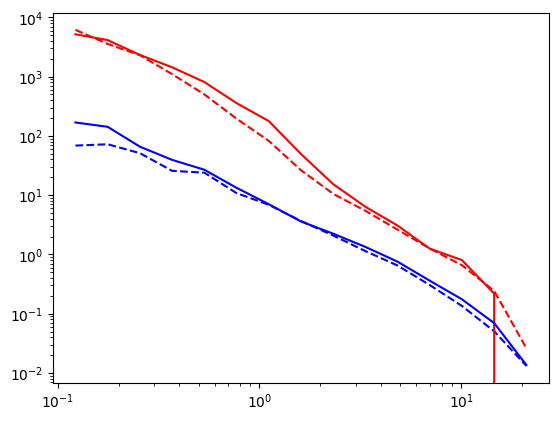

In [93]:
plt.loglog(rbin_centers, xi_red_cam, c='r', ls='--')
plt.loglog(rbin_centers, xi_blue_cam, c='b', ls='--')

plt.loglog(rbin_centers, xi_red_true, c='r')
plt.loglog(rbin_centers, xi_blue_true, c='b')

(0.2, 2.0)

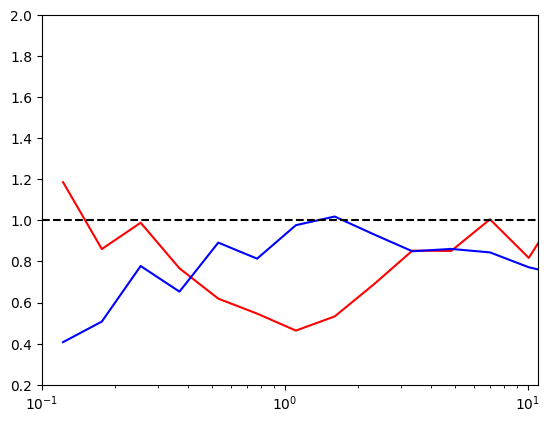

In [ ]:
plt.semilogx(rbin_centers, xi_red_cam / xi_red_true, c='r', ls='-')
plt.semilogx(rbin_centers, xi_blue_cam / xi_blue_true, c='b', ls='-')

plt.axhline(1.0, ls='--', c='k')

plt.xlim(0.1, 11)
plt.ylim(0.2, 2.)

#i think this reproduces haley's results
# doesn't seem to get much affected by adding scatter or not...
# NOTE: double check, but mpeak mass bin cut at the beginning does not seem to affect output

## Repeat with multicam a_{1/2} only

In [ ]:

# -----------------------------
# MultiCAM targets & features
# -----------------------------
# Define Targets & features
color = hydro_mstar_cut['color']
targets = np.array([color]).T
features = hydro_mstar_pred['a12']
features = np.array(features).reshape(-1, 1)
print(targets.shape, features.shape)



(4054, 1) (4054, 1)


In [21]:
spearmanr(hydro_mstar_cut['g-i'], hydro_mstar_cut['a12'])

SignificanceResult(statistic=np.float64(-0.583213042338797), pvalue=np.float64(0.0))

In [75]:
pred = multicam_prediction(features, features, targets)


In [76]:

def generate_randoms(Lbox, number):
    """Generate randoms to be used for tpcf_jackknife
    Args:
        Lbox: size of TNG simulation box
        number: desired number of randoms, i.e. 10,000
    Return:
        Nran: xyz formatted array of uniform random variables
    """
    Xran = np.random.uniform(0, Lbox, number)
    Yran = np.random.uniform(0, Lbox, number)
    Zran = np.random.uniform(0, Lbox, number)
    Nran = return_xyz_formatted_array(Xran, Yran, Zran)
    return Nran


In [77]:
# Note use mpeak_cut cause that's what we apply mcam to
hydro_mstar_pred['pred_color'] = pred[:, 0]


/var/folders/yl/5w7yl6bn1tsc5fjrdtsrsjhh0000gn/T/ipykernel_89997/2345035714.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  hydro_mstar_pred['pred_color'] = pred[:, 0]


In [78]:

Lbox = 110.7 * TNG_H
rbins = np.logspace(np.log10(0.1), np.log10(24.9), 16)
rbin_centers = 0.5 * (rbins[1:] + rbins[:-1])
randoms = generate_randoms(Lbox, 50000)

In [20]:
xi_truth, cov_truth = tpcf_jackknife(
        return_xyz_formatted_array(hydro_mstar_cut['x'], hydro_mstar_cut['y'], hydro_mstar_cut['z']),
        randoms, rbins, Nsub=3, period=Lbox, num_threads='max')


In [21]:

xi_pred, cov_pred = tpcf_jackknife(
        return_xyz_formatted_array(hydro_mstar_pred['x'], hydro_mstar_pred['y'], hydro_mstar_pred['z']),
        randoms, rbins, Nsub=3, period=Lbox, num_threads='max')

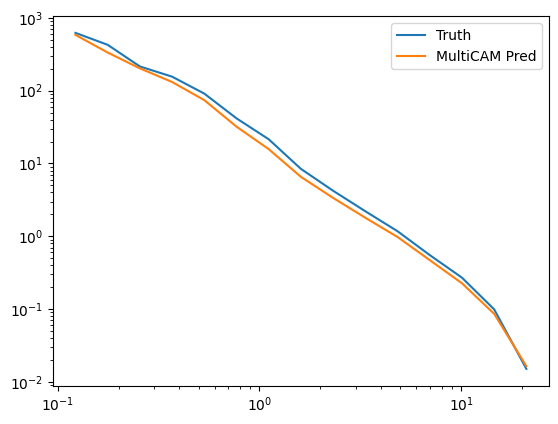

In [22]:
plt.plot(rbin_centers, xi_truth, label = "Truth")
plt.plot(rbin_centers, xi_pred, label = "MultiCAM Pred")
plt.yscale("log")
plt.xscale("log")
plt.legend()

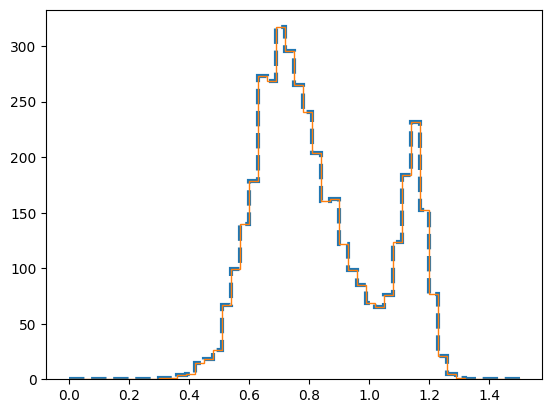

In [79]:
bins = np.linspace(0.0, 1.5, 51)

plt.hist(hydro_mstar_cut["g-i"], bins = bins, histtype = "step", linestyle = "--", linewidth = 3)
plt.hist(hydro_mstar_pred['pred_color'], bins = bins, histtype = "step")
plt.show()

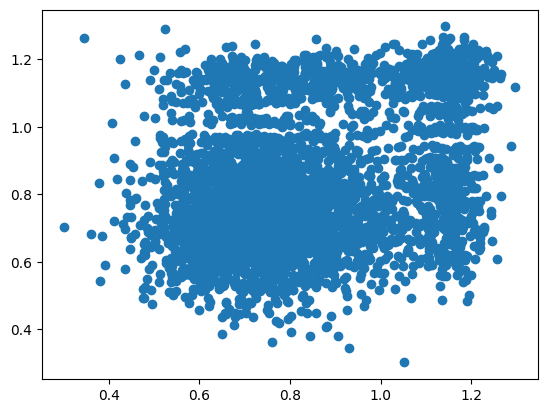

In [80]:
plt.scatter(hydro_mstar_cut['g-i'], hydro_mstar_pred['pred_color']) # not the same

In [81]:
COLOR_CUT = 1.0 

red_pred = hydro_mstar_pred[hydro_mstar_pred['pred_color'] > COLOR_CUT]
blue_pred = hydro_mstar_pred[hydro_mstar_pred['pred_color'] <= COLOR_CUT]

red_table = hydro_mstar_cut[hydro_mstar_cut['g-i'] > COLOR_CUT]
blue_table = hydro_mstar_cut[hydro_mstar_cut['g-i'] <= COLOR_CUT]


print(len(red_pred), len(blue_pred), len(red_table), len(blue_table))

983 3071 983 3071


In [85]:
## Compute TPCF ###
from halotools.mock_observables import return_xyz_formatted_array, tpcf_jackknife

Lbox = 110.7 * TNG_H
rbins = np.logspace(np.log10(0.1), np.log10(24.9), 16)
rbin_centers = 0.5 * (rbins[1:] + rbins[:-1])
randoms = generate_randoms(Lbox, 50000)



In [86]:

xi_red_truth, cov_red_truth = tpcf_jackknife(
        return_xyz_formatted_array(red_table['x'], red_table['y'], red_table['z']),
        randoms, rbins, Nsub=3, period=Lbox, num_threads='max')


In [87]:

xi_blue_truth, cov_blue_truth = tpcf_jackknife(
        return_xyz_formatted_array(blue_table['x'], blue_table['y'], blue_table['z']),
        randoms, rbins, Nsub=3, period=Lbox, num_threads='max')


In [88]:

xi_red_pred, cov_red_pred = tpcf_jackknife(
        return_xyz_formatted_array(red_pred['x'], red_pred['y'], red_pred['z']),
        randoms, rbins, Nsub=3, period=Lbox, num_threads='max')


In [89]:

xi_blue_pred, cov_blue_pred = tpcf_jackknife(
        return_xyz_formatted_array(blue_pred['x'], blue_pred['y'], blue_pred['z']),
        randoms, rbins, Nsub=3, period=Lbox, num_threads='max')

In [91]:
from multicam.qt import qt 
def cam(proxy, observed, cond_proxy, cond_observed, mass_min, mass_max):
    """Updated CAM using Phil's QT
    Note: Returns mask_gal and mask_halo in order to find galaxies and haloes
    in defined mass bin, i.e. subhalo_data[mask_gal], dmo_data[mask_halo]. 
    """
    stellar_mass_pred = qt(proxy, observed)

    mask_gal = (observed >= mass_min) & (observed < mass_max)
    cond_observed_bin = cond_observed[mask_gal]

    mask_halo = (stellar_mass_pred >= mass_min) & (stellar_mass_pred < mass_max)
    cond_proxy_bin = cond_proxy[mask_halo]

    cond_proxy_pred = qt(cond_proxy_bin, cond_observed_bin)

    return cond_observed_bin, cond_proxy_pred, mask_gal, mask_halo


In [93]:
low = 9.5
high = 10.2
color_bin_cam, color_pred_cam, mask_gal, mask_halo = cam(
        np.log10(hydro_full['mpeak'].to_numpy()), 
        np.log10(hydro_full['StellarMass'].to_numpy()), 
        hydro_full['z12'].to_numpy(), 
        hydro_full['g-i'].to_numpy(), 
        low, high)

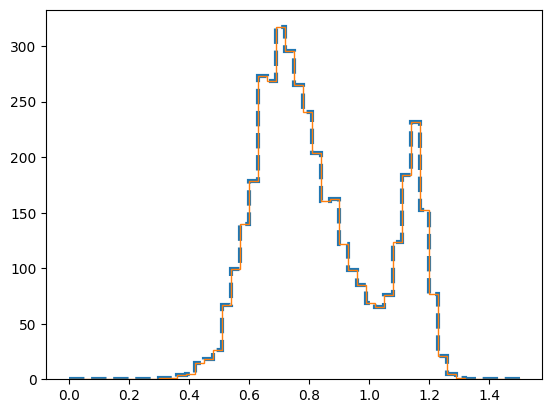

In [94]:
bins = np.linspace(0.0, 1.5, 51)

plt.hist(hydro_mstar_cut["g-i"], bins = bins, histtype = "step", linestyle = "--", linewidth = 3)
plt.hist(color_pred_cam, bins = bins, histtype = "step")
plt.show()

In [95]:
halo_bin = hydro_full[mask_halo].copy()
hydro_bin = hydro_full[mask_gal].copy()
halo_bin['color_pred_cam'] = color_pred_cam
hydro_bin['color'] = color_bin_cam
halo_bin

,SubhaloMass,StellarMass,x,y,z,logSubhaloMass,logStellarMass,vpeak,a12,mpeak,...,mpeak_mah93,mpeak_mah94,mpeak_mah95,mpeak_mah96,mpeak_mah97,mpeak_mah98,mpeak_mah99,g-i,z12,color_pred_cam
22,4.092979e+11,1.634936e+10,1.857714,25.990385,19.931873,11.612040,10.213501,219.66856,0.344828,5.439045e+11,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.041630,1.90,1.005073
26,3.041727e+11,1.426524e+10,0.822764,26.144829,19.978884,11.483120,10.154279,198.72200,0.290698,3.719824e+11,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.093975,2.44,1.147779
27,2.883535e+11,8.203994e+09,1.252321,26.284533,19.722652,11.459926,9.914025,155.84532,0.354610,2.919132e+11,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.535936,1.82,0.947065
28,3.212165e+11,1.061568e+10,0.617334,26.386446,19.905940,11.506798,10.025948,161.09685,0.444444,4.735706e+11,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.061354,1.25,0.751734
29,3.033128e+11,1.394747e+10,0.964003,27.382607,17.868130,11.481891,10.144496,200.30531,0.322581,4.341942e+11,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.086931,2.10,1.101391
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39330,1.196596e+11,5.075468e+09,8.193717,38.069378,26.611917,11.077948,9.705476,145.23163,0.400000,3.309459e+11,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.910683,1.50,0.832216
40180,1.318226e+11,7.648536e+09,12.185365,49.848890,48.857555,11.119989,9.883578,185.76553,0.249377,2.747728e+11,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.168732,3.01,1.194427
40381,1.401626e+11,5.255136e+09,38.820156,69.901560,38.579685,11.146632,9.720584,154.96550,0.344828,2.256785e+11,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.160772,1.90,1.061363
40431,1.379732e+11,4.158778e+09,32.970360,1.496312,70.444360,11.139794,9.618966,137.68964,0.465116,2.219580e+11,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.996534,1.15,0.739487


In [ ]:
import numpy as np
from halotools.mock_observables import tpcf_jackknife
from halotools.mock_observables import return_xyz_formatted_array

# ---------------------------------------------------
# Color split
# ---------------------------------------------------

halo_bin['red_pred_cam'] = halo_bin['color_pred_cam'].where(
    halo_bin['color_pred_cam'] > COLOR_CUT
)

halo_bin['blue_pred_cam'] = halo_bin['color_pred_cam'].where(
    halo_bin['color_pred_cam'] <= COLOR_CUT
)


# ---------------------------------------------------
# Masks (correct NaN handling)
# ---------------------------------------------------

mask_red = halo_bin['red_pred_cam'].notna()
mask_blue = halo_bin['blue_pred_cam'].notna()

# ---------------------------------------------------
# Build xyz arrays
# ---------------------------------------------------

xyz_red = return_xyz_formatted_array(
    halo_bin.loc[mask_red, 'x'].to_numpy(),
    halo_bin.loc[mask_red, 'y'].to_numpy(),
    halo_bin.loc[mask_red, 'z'].to_numpy(),
)

xyz_blue = return_xyz_formatted_array(
    halo_bin.loc[mask_blue, 'x'].to_numpy(),
    halo_bin.loc[mask_blue, 'y'].to_numpy(),
    halo_bin.loc[mask_blue, 'z'].to_numpy(),
)

# ---------------------------------------------------
# Two-point correlation functions
# ---------------------------------------------------

xi_red_cam, cov_red_cam = tpcf_jackknife(
    xyz_red,
    randoms,
    rbins,
    Nsub=3,
    period=Lbox,
    num_threads='max'
)

xi_blue_cam, cov_blue_cam = tpcf_jackknife(
    xyz_blue,
    randoms,
    rbins,
    Nsub=3,
    period=Lbox,
    num_threads='max'
)


In [98]:
from scipy.stats import spearmanr
spearmanr(color_pred_cam, hydro_mstar_pred['pred_color'])

SignificanceResult(statistic=np.float64(0.9985989953097323), pvalue=np.float64(0.0))

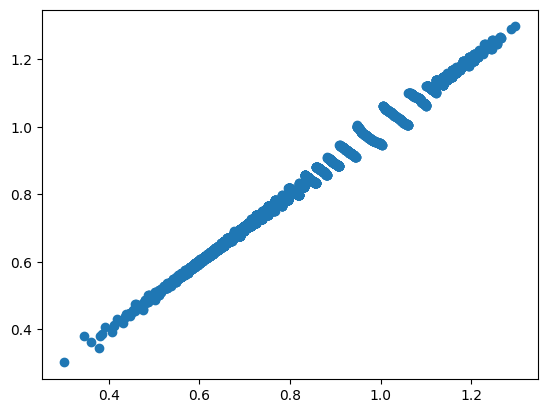

In [99]:
plt.scatter(color_pred_cam, hydro_mstar_pred['pred_color']) # not the same

In [100]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# Set global font size for all text elements (optional, can be overridden)
mpl.rcParams['font.size'] = 20

# Set global font size for axis labels
mpl.rcParams['axes.labelsize'] = 25

# Set global font size for tick numbers
mpl.rcParams['xtick.labelsize'] = 25
mpl.rcParams['ytick.labelsize'] = 25

# Set tick widths and sizes globally
mpl.rcParams['xtick.major.width'] = 3
mpl.rcParams['ytick.major.width'] = 3
mpl.rcParams['xtick.minor.width'] = 3
mpl.rcParams['ytick.minor.width'] = 3

mpl.rcParams['xtick.minor.size'] = 6
mpl.rcParams['ytick.minor.size'] = 6
mpl.rcParams['xtick.major.size'] = 7
mpl.rcParams['ytick.major.size'] = 7

# Set axes line width globally
mpl.rcParams['axes.linewidth'] = 3 # Sets the width of the spines

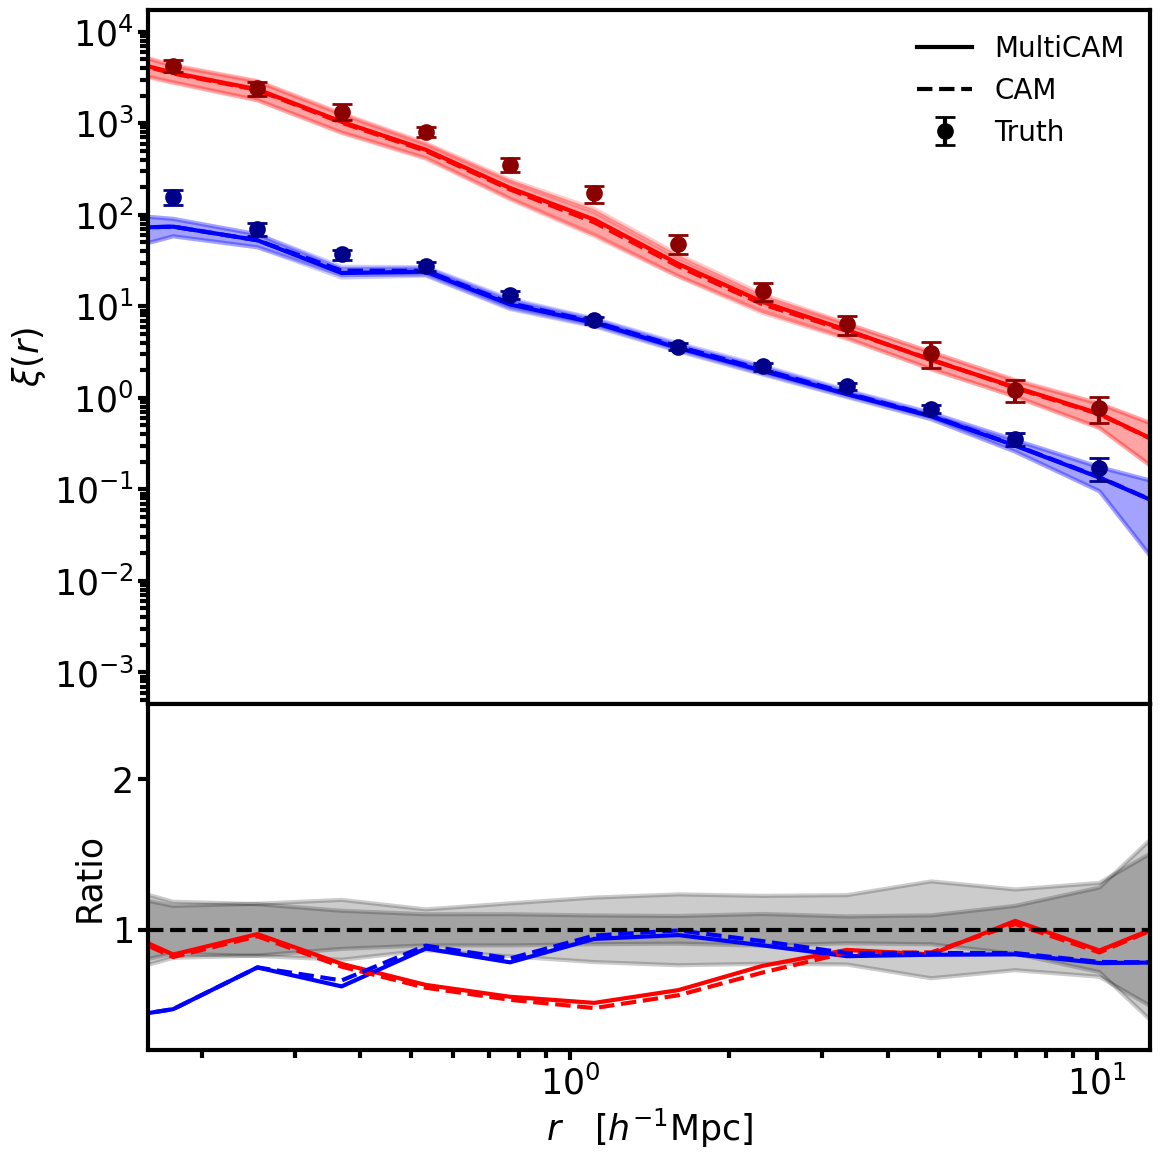

In [101]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(
    2, 1,
    figsize=(12, 12),
    sharex=True,
    gridspec_kw={
        'height_ratios': [2, 1],
        'hspace': 0
    }
)
# ---------------- Top panel ----------------

#####################################

axes[0].plot(
    rbin_centers, xi_red_pred,
    color='red', linewidth=3
)
axes[0].fill_between(
    rbin_centers,
    xi_red_pred - np.sqrt(np.diag(cov_red_pred)),
    xi_red_pred + np.sqrt(np.diag(cov_red_pred)),
    color='red', alpha=0.2, linewidth=3
)

#####################################

axes[0].plot(
    rbin_centers, xi_blue_pred,
    color='blue', linewidth=3
)
axes[0].fill_between(
    rbin_centers,
    xi_blue_pred - np.sqrt(np.diag(cov_blue_pred)),
    xi_blue_pred + np.sqrt(np.diag(cov_blue_pred)),
    color='blue', alpha=0.2, linewidth=3
)

#####################################

axes[0].plot(
    rbin_centers, xi_red_cam,
    color='red', linestyle = '--', linewidth=3
)
axes[0].fill_between(
    rbin_centers,
    xi_red_cam - np.sqrt(np.diag(cov_red_cam)),
    xi_red_cam + np.sqrt(np.diag(cov_red_cam)),
    color='red', alpha=0.2, linewidth=3
)

#####################################

axes[0].plot(
    rbin_centers, xi_blue_cam,
    color='blue', linestyle = '--', linewidth=3
)
axes[0].fill_between(
    rbin_centers,
    xi_blue_cam - np.sqrt(np.diag(cov_blue_cam)),
    xi_blue_cam + np.sqrt(np.diag(cov_blue_cam)),
    color='blue', alpha=0.2, linewidth=3
)

###################################################



# Common errorbar style
err_kwargs = dict(
    fmt='o',
    markersize=10,
    color='darkred',
    elinewidth=3,
    capsize=7,
    capthick=3,
    markeredgewidth=2,
    alpha=1.0
)

axes[0].errorbar(
    rbin_centers, xi_red_truth,
    yerr=np.sqrt(np.diag(cov_red_truth)),
    **err_kwargs
)


# Common errorbar style
err_kwargs = dict(
    fmt='o',
    markersize=10,
    color='darkblue',
    elinewidth=3,
    capsize=7,
    capthick=3,
    markeredgewidth=2,
    alpha=1.0
)

axes[0].errorbar(
    rbin_centers, xi_blue_truth,
    yerr=np.sqrt(np.diag(cov_blue_truth)),
    **err_kwargs
)


################################

# --- Proxy handles ---
multicam_handle = Line2D(
    [0], [0],
    color='black',
    lw=3,
    linestyle='-',
    label='MultiCAM'
)

cam_handle = Line2D(
    [0], [0],
    color='black',
    lw=3,
    linestyle='--',
    label='CAM'
)

# Errorbar proxy (this MUST be created with errorbar)
truth_handle = axes[0].errorbar(
    [0], [0],
    yerr=[0.3],          # arbitrary nonzero value
    fmt='o',
    color='black',
    markersize=10,
    elinewidth=3,
    capsize=7,
    capthick=3,
    markeredgewidth=2,
    label='Truth'
)

# --- Legend ---
axes[0].legend(
    handles=[multicam_handle, cam_handle, truth_handle],
    frameon=False,
    fontsize=20
)


axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlim(10**(-0.8), 10**(1.1)) # Based on Hadzhiyska
axes[0].set_ylabel(r'$\xi(r)$')

# ---------------- Bottom panel ----------------
axes[1].plot(
    rbin_centers, xi_red_pred / xi_red_truth, color = "red", linewidth=3, label = 'MultiCAM Red'
)

axes[1].plot(
    rbin_centers, xi_blue_pred / xi_blue_truth, color = "blue", linewidth=3, label = 'MultiCAM Blue'
)

axes[1].plot(
    rbin_centers, xi_red_cam / xi_red_truth, color = "red", linestyle='--', linewidth=3, label = 'CAM Red'
)

axes[1].plot(
    rbin_centers, xi_blue_cam / xi_blue_truth, color = "blue", linestyle='--', linewidth=3, label = 'CAM Blue'
)

axes[1].fill_between(
    rbin_centers,
    1 - (np.sqrt(np.diag(cov_blue_truth))/xi_blue_truth),
    1 + (np.sqrt(np.diag(cov_blue_truth))/xi_blue_truth),
    color='k', alpha=0.2, linewidth=3
)

axes[1].fill_between(
    rbin_centers,
    1 - (np.sqrt(np.diag(cov_red_truth))/xi_red_truth),
    1 + (np.sqrt(np.diag(cov_red_truth))/xi_red_truth),
    color='k', alpha=0.2, linewidth=3
)



axes[1].axhline(1.0, color='black', linestyle='--', linewidth=3)
axes[1].set_xlabel(r'$r \quad [h^{-1} \rm Mpc]$')
axes[1].set_ylabel('Ratio')
axes[1].set_ylim(0.2, 2.5)

# ---------------- Final formatting ----------------
plt.tight_layout()
fig.savefig('multicam_hydro_a12_noscatter_sham.png', dpi=300, bbox_inches='tight')
plt.show()